In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [11]:
df = pd.read_csv(
    "../employee_data_cleaned.csv"
)

In [12]:
df = df.drop(columns=['Employee_ID', 'Name', 'Email', 'Joining_Date'])
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())
df.head()

,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition
0,Male,38.0,Marketing,Karachi,4,Intermediate,Senior,111512.0,7.900000,True,Full-time,169,150,77,1.1,No
1,Female,35.0,Design,Rawalpindi,8,Intermediate,Senior,111512.0,6.700000,True,Part-time,183,7,11,2.5,No
2,Female,23.0,Design,Lahore,3,MPhil,Junior,56050.0,7.443687,True,Full-time,177,6,29,4.5,No
3,Female,42.0,Support,Islamabad,6,Master,Senior,118533.0,7.443687,True,Full-time,188,18,71,1.9,No
4,Male,35.0,IT,Peshawar,10,MPhil,Junior,77905.0,9.300000,True,Full-time,190,30,18,3.1,No


In [13]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

le = LabelEncoder()
df_encoded = df.copy()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

C:\Users\Milon\AppData\Local\Temp\ipykernel_22396\1282757758.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition
0,1,38.0,4,2,4,1,4,111512.0,7.900000,True,1,169,150,77,1.1,0
1,0,35.0,0,6,8,1,4,111512.0,6.700000,True,2,183,7,11,2.5,0
2,0,23.0,0,3,3,2,0,56050.0,7.443687,True,1,177,6,29,4.5,0
3,0,42.0,7,1,6,3,4,118533.0,7.443687,True,1,188,18,71,1.9,0
4,1,35.0,3,5,10,2,0,77905.0,9.300000,True,1,190,30,18,3.1,0


In [14]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (400, 15)
Testing size: (100, 15)


In [15]:
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.51


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.62


In [17]:
print("Decision Tree vs Random Forest")
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print()
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Decision Tree vs Random Forest
Decision Tree Accuracy: 0.51
Random Forest Accuracy: 0.62

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        81
           1       0.15      0.21      0.17        19

    accuracy                           0.62       100
   macro avg       0.47      0.46      0.46       100
weighted avg       0.67      0.62      0.64       100



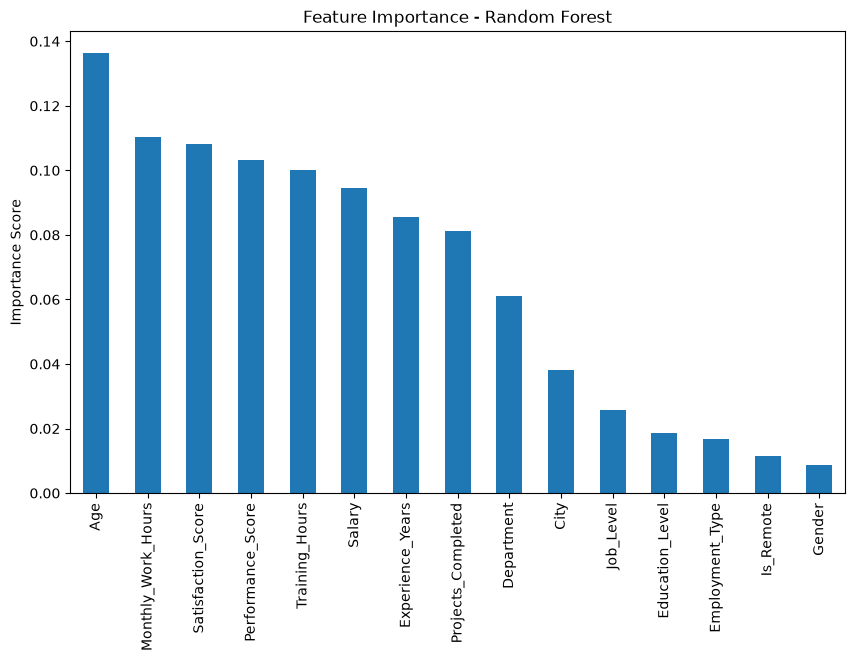

In [18]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.show()

In [19]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)
ada_accuracy = accuracy_score(y_test, ada_pred)

print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.8


In [20]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.79


In [21]:
voting_model = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
        ('lr', LogisticRegression(max_iter=1000))
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)
voting_pred = voting_model.predict(X_test)
voting_accuracy = accuracy_score(y_test, voting_pred)

print("Voting Classifier Accuracy:", voting_accuracy)

Voting Classifier Accuracy: 0.79


f:\machine-learning-beginner-to-advanced\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


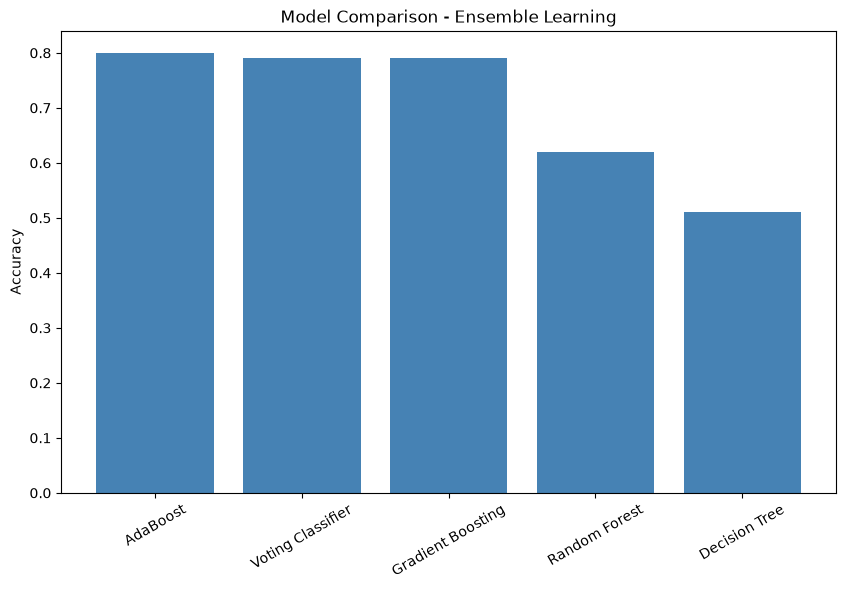

,Model,Accuracy
2,AdaBoost,0.80
4,Voting Classifier,0.79
3,Gradient Boosting,0.79
1,Random Forest,0.62
0,Decision Tree,0.51


In [22]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'Voting Classifier'],
    'Accuracy': [dt_accuracy, rf_accuracy, ada_accuracy, gb_accuracy, voting_accuracy]
})

results = results.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(results['Model'], results['Accuracy'], color='steelblue')
plt.ylabel('Accuracy')
plt.title('Model Comparison - Ensemble Learning')
plt.xticks(rotation=30)
plt.show()

results